# Probe-Guided Debiasing for Brain-Tumour MRI: Audit, Independent Evaluation and a Fair Comparison with 6 Literature Methods (v8, final PhD pipeline)

## What we are doing, in simple words
1. **Problem.** Public brain-tumour MRI data gives about 97% accuracy, but a model can be right for the wrong reason (brightness, background, size, file type) instead of reading the tumour.
2. **Audit (the blindfold test).** We train small models that never see the tumour (only brightness histogram, background, size, file info). They already reach about 94%. So part of the benchmark can be solved by cheating.
3. **Honest test.** We take the images where those blindfolded models are confidently wrong (the **Counter-Shortcut Set**). Accuracy of real models drops there. This is the real reliability gap.
4. **Independent check (new in v8).** The first Counter-Shortcut Set (A) uses the same probes our methods train against, which is circular. So we build a second set (B) from a **different probe family** (thumbnail + noise/frequency statistics) that no method ever sees.
5. **A natural test.** One group of gliomas (a different scanner) never appears in Training. We report accuracy and tumour-detection sensitivity on it.
6. **Methods.** We compare **6 literature methods** (ERM, GroupDRO, JTT, debiased focal loss, full-strength product-of-experts, contrast/framing augmentation) against **3 probe-guided variants of ours** (PoE at strength 0.5, IPW, IPW+CFR) on **3 architectures** with **3 seeds** on the main one.
7. **Fair selection.** Our final variant is chosen by a rule written **before** looking at test results (validation only, section 6b).
8. **Honest verdict.** The notebook prints whether our method really ranks first. If it does not, the paper reports that.

## Why each step exists
Each section below starts with a short "Why" so you can explain it in your thesis and viva.

## What is new and what is not (be honest in the paper)
Not new alone: PoE, inverse propensity weighting, focal debiasing, GroupDRO, JTT. **New here:** (a) a bias expert built automatically from a ladder of blindfold probes (no group labels needed), (b) the Counter-Shortcut evaluation with an independent probe family, (c) the missing-cell analysis and recovery curve, (d) the test-time shortcut dial, (e) a pre-set selection rule. Prior work to cite: Wallis and Buvat 2022 (Clever Hans in a brain tumour MRI dataset).

Runtime on a Kaggle T4: about 6 h full (resumable). `QUICK=1` runs one architecture and one seed (about 1.5 h).

In [1]:
import os, io, glob, re, json, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from PIL import Image
from tqdm.auto import tqdm
from scipy import ndimage as ndi
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import wilcoxon, skew
from skimage.filters import threshold_otsu, gaussian
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import imagehash
warnings.filterwarnings("ignore")
E = os.environ.get
DATA_ROOT = E("DATA_ROOT", "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset")
EXT_ROOT = E("EXT_ROOT", "")            # optional external dataset: one folder per class (see section 12)
QUICK = int(E("QUICK", 0))
ARCHS = [a for a in E("ARCHS", "convnext_tiny,resnet50,efficientnet_b0").split(",") if a]
if QUICK: ARCHS = ARCHS[:1]
sp_ = lambda s: [int(v) for v in s.split(",") if v != ""]
SEEDS_MAIN = [0] if QUICK else sp_(E("SEEDS_MAIN", "0,1,2")); SEEDS_OTHER = sp_(E("SEEDS_OTHER", "0"))
seeds_of = {a: (SEEDS_MAIN if i == 0 else SEEDS_OTHER) for i, a in enumerate(ARCHS)}; ARCH1 = ARCHS[0]
FS_SEEDS = [0] if QUICK else sp_(E("FS_SEEDS", "0,1,2")); KS = [0, 4, 8, 16, 32]
IMG, EPOCHS, BATCH, LR = 128, int(E("EPOCHS", 4 if QUICK else 6)), 64, 3e-4
DRO_ETA, EPOCHS_J, JTT_LAMBDA, DFL_GAMMA = 0.05, 2, 5.0, 2.0
DROP_AUG, NFOLD, MIN_CELL, SUB = int(E("DROP_AUG", 1)), 5, int(E("MIN_CELL", 30)), (int(E("SUB", 0)) or None)
OUT = "outputs"; RUNS = f"{OUT}/runs"; MODELS = f"{OUT}/models"
for d in (OUT, RUNS, MODELS): os.makedirs(d, exist_ok=True)
dev = "cuda" if torch.cuda.is_available() else "cpu"
def get_w(name):
    try:
        w = torchvision.models.get_model_weights(name).DEFAULT; torchvision.models.get_model(name, weights=w); return w
    except Exception: print("no pretrained weights for", name, "(random init)"); return None
WEIGHTS = {b: get_w(b) for b in ARCHS}
json.dump(dict(ARCHS=ARCHS, seeds_of=seeds_of, FS_SEEDS=FS_SEEDS, EPOCHS=EPOCHS, DROP_AUG=DROP_AUG, JTT_LAMBDA=JTT_LAMBDA, DFL_GAMMA=DFL_GAMMA), open(f"{OUT}/config.json", "w"))
print(dev, ARCHS, seeds_of)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 209MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 233MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 169MB/s]

cuda ['convnext_tiny', 'resnet50', 'efficientnet_b0'] {'convnext_tiny': [0, 1, 2], 'resnet50': [0], 'efficientnet_b0': [0]}


## 1. Data forensics and cells
**Why:** every image carries a file-format fingerprint (colour mode, JPEG table, native size). Grouping images by class x format shows which class/domain combinations exist, and which are **missing** from Training. The missing cell is our natural test of generalisation.

In [2]:
rows = []
for sp in ["Training", "Testing"]:
    for c in sorted(os.listdir(f"{DATA_ROOT}/{sp}")):
        for f in sorted(glob.glob(f"{DATA_ROOT}/{sp}/{c}/*")):
            with Image.open(f) as im:
                q = getattr(im, "quantization", None) or {}
                rows.append(dict(path=f, orig_split=sp, label=c, w=im.size[0], h=im.size[1], mode=im.mode, kb=os.path.getsize(f)/1024, q0=int(sum(q[0][:8])) if 0 in q else -1))
df = pd.DataFrame(rows); df["aug"] = df.path.map(lambda p: "aug" in os.path.basename(p).lower())
print("pre-augmented files:", int(df.aug.sum()), "(dropped)" if DROP_AUG else "(kept)")
if DROP_AUG: df = df[~df.aug]
if SUB: df = df.groupby("label").sample(SUB, random_state=0)
df = df.sort_values("path").reset_index(drop=True); N = len(df)
classes = sorted(df.label.unique()); K = len(classes); NOTU = classes.index("notumor"); y = df.label.map({c: i for i, c in enumerate(classes)}).values.astype(np.int64)
top = [v for v in df.q0.value_counts().index if v > 0][:2]; df["qb"] = df.q0.map(lambda v: f"q{v}" if v in top else "qoth")
msz = df.groupby(["w","h"]).size().idxmax(); df["sz"] = np.where((df.w == msz[0]) & (df.h == msz[1]), "std", "other")
df["md"] = df["mode"].map(lambda m: "L" if m == "L" else "RGB"); df["fg"] = df.md + "|" + df.qb + "|" + df.sz
fgs = sorted(df.fg.unique()); fgid = df.fg.map({g: i for i, g in enumerate(fgs)}).values.astype(np.int64); NFG = len(fgs)
cid = (y*NFG + fgid).astype(np.int64); NC = K*NFG; cell_names = [f"{classes[c//NFG][:4]}|{fgs[c%NFG]}" for c in range(NC)]
tr_orig = (df.orig_split == "Training").values; te_orig = ~tr_orig
trn, ten = np.bincount(cid[tr_orig], minlength=NC), np.bincount(cid[te_orig], minlength=NC)
print(pd.DataFrame({"train": trn, "test": ten}, index=cell_names).query("train + test > 0").to_string())
miss = [c for c in range(NC) if trn[c] == 0 and ten[c] >= 20]; MC = np.isin(cid, miss)
print("\nMISSING CELLS (absent from Training, present in Testing):", [(cell_names[c], int(ten[c])) for c in miss])

pre-augmented files: 203 (dropped)
                     train  test
glio|L|q116|std       1173   226
glio|RGB|q38|other       0    76
glio|RGB|q38|std       227    98
meni|L|q116|std        543   154
meni|RGB|q38|other     128   117
meni|RGB|q38|std       624    26
meni|RGB|qoth|other      5     0
notu|L|q116|other       18     6
notu|L|qoth|other        5     0
notu|RGB|q116|other    866   382
notu|RGB|q116|std        9     3
notu|RGB|q38|other     431     9
notu|RGB|q38|std         8     0
notu|RGB|qoth|other     63     0
pitu|L|q116|other        8     7
pitu|L|q116|std        599   316
pitu|RGB|q38|other      64     1
pitu|RGB|q38|std       729    76

MISSING CELLS (absent from Training, present in Testing): [('glio|RGB|q38|other', 76)]


## 2. Preprocessing and descriptors
**Why:** we compute simple numbers that never look at tumour anatomy. Family A (metadata, geometry, contrast histogram, background) is used both to **measure** shortcuts and to **train** our debiasing methods. Family B (a tiny 12x12 thumbnail, and noise / frequency / JPEG-blockiness statistics) is used **only for evaluation**, so the test is independent.

In [3]:
S = 256
def brain_mask(a):
    b = gaussian(a, 1.5); m = b > threshold_otsu(b)*0.5
    m = ndi.binary_fill_holes(ndi.binary_opening(m, iterations=2)); lab, n = ndi.label(m)
    return np.ones_like(m) if n == 0 else lab == (np.argmax(ndi.sum(m, lab, range(1, n+1))) + 1)
rs = lambda z, mode: np.asarray(Image.fromarray(z).resize((IMG, IMG), mode))
def noise_feats(ga):                         # family B: noise, frequency and JPEG-blockiness statistics of the native image
    f1 = ndi.laplace(ga).var()/(ga.var() + 1e-8); f2 = (ga - ndi.uniform_filter(ga, 3)).std()
    h, w = ga.shape; c = ga[max(h//2 - 64, 0):h//2 + 64, max(w//2 - 64, 0):w//2 + 64]
    if c.shape != (128, 128): c = np.asarray(Image.fromarray((ga*255).astype(np.uint8)).resize((128, 128)), np.float32)/255
    P = np.abs(np.fft.fftshift(np.fft.fft2(c - c.mean())))**2; yy, xx = np.indices(P.shape); r = np.hypot(yy - 64, xx - 64)
    fb = np.array([P[(r >= a) & (r < b)].sum() for a, b in [(1, 8), (8, 20), (20, 40), (40, 64)]]); fb = fb/(fb.sum() + 1e-12)
    dx = np.abs(np.diff(ga, axis=1)); cols = np.arange(dx.shape[1]); blk = dx[:, cols % 8 == 7].mean()/(dx[:, cols % 8 != 7].mean() + 1e-8)
    return np.r_[f1, f2, fb, blk]
CACHE = f"{OUT}/cache_v8_N{N}.npz"
if os.path.exists(CACHE):
    z = np.load(CACHE); Xr, Sm, PH, F2, F3, F4, F5 = [z[k] for k in ["Xr", "Sm", "PH", "F2", "F3", "F4", "F5"]]; print("loaded cache")
else:
    Xr = np.zeros((N,IMG,IMG), np.uint8); Sm = np.zeros((N,32,32), np.float32); PH = np.zeros(N, np.uint64); F2, F3, F4, F5 = [], [], [], []
    for i, p in enumerate(tqdm(df.path)):
        with Image.open(p) as im: g0 = im.convert("L")
        g = g0.resize((S, S), Image.BILINEAR); a = np.asarray(g, np.float32)/255
        Xr[i] = rs(np.asarray(g), Image.BILINEAR); Sm[i] = np.asarray(g.resize((32, 32)), np.float32)/255; PH[i] = int(str(imagehash.phash(g)), 16)
        m = brain_mask(a); m = np.ones_like(m) if m.mean() < .05 else m
        v = a[m]; vn = v/(np.percentile(v, 98) + 1e-6); hh = np.histogram(np.clip(vn, 0, 1.2), bins=12, range=(0, 1.2))[0]/len(vn)
        F2.append(np.r_[hh, vn.mean(), vn.std(), skew(vn), np.percentile(vn, [5, 25, 50, 75, 95])])
        bg = a[~m] if (~m).any() else np.zeros(1); grid = np.where(m, 0, a).reshape(8, 32, 8, 32).mean((1, 3)).ravel()
        F3.append(np.r_[bg.mean(), bg.std(), (~m).mean(), a[:8].mean(), a[-8:].mean(), a[:, :8].mean(), a[:, -8:].mean(), grid])
        F4.append(noise_feats(np.asarray(g0, np.float32)/255)); F5.append(np.asarray(g.resize((12, 12), Image.BILINEAR), np.float32).ravel()/255)
    F2, F3, F4, F5 = [np.array(f, np.float32) for f in (F2, F3, F4, F5)]; np.savez(CACHE, Xr=Xr, Sm=Sm, PH=PH, F2=F2, F3=F3, F4=F4, F5=F5)
F0 = np.c_[(df.md == "RGB").astype(float), df.q0]; F1 = np.c_[df.w, df.h, df.w/df.h, df.kb*1024/(df.w*df.h)]
FU = np.c_[F0, F1, F2, F3]; print("family A (training + measuring):", FU.shape[1], "features | family B (evaluation only):", F4.shape[1] + F5.shape[1], "features")
def pc(a): return np.unpackbits(np.ascontiguousarray(a).view(np.uint8).reshape(*a.shape, 8), axis=-1).sum(-1)
cand_ = set()
for s in range(0, N, 64):
    ii, jj = np.where(pc(PH[s:s+64, None] ^ PH[None, :]) <= 4); cand_ |= {(a+s, b) for a, b in zip(ii, jj) if a+s < b}
Sf = Sm.reshape(N, -1); Sf = Sf - Sf.mean(1, keepdims=True); Sf /= (np.linalg.norm(Sf, axis=1, keepdims=True) + 1e-8)
Ed = np.array([(a, b) for a, b in cand_ if Sf[a] @ Sf[b] >= .98]).reshape(-1, 2)
df["grp"] = connected_components(coo_matrix((np.ones(len(Ed)), (Ed[:,0], Ed[:,1])), shape=(N, N)), directed=False)[1] if len(Ed) else np.arange(N)
print("near-duplicate pairs:", len(Ed), "| images in duplicate groups:", int((df.groupby("grp").grp.transform("size") > 1).sum()))
okcell = (np.bincount(cid, minlength=NC) >= MIN_CELL); ctab = pd.crosstab(df.fg, df.label)
strict = [i for i, g in enumerate(fgs) if all(ctab.loc[g, c] >= 30 for c in classes)]; fc_strict = np.isin(fgid, strict)
def make_splits(seed):
    allix = np.arange(N); fl = [f[1] for f in StratifiedGroupKFold(NFOLD, shuffle=True, random_state=seed).split(np.zeros(N), cid, df.grp.values)]
    out = [(f"f{k}", np.setdiff1d(allix, np.r_[fl[k], fl[(k+1) % NFOLD]]), fl[(k+1) % NFOLD], fl[k]) for k in range(NFOLD)]
    te = np.where(te_orig)[0]; tr_all = np.where(tr_orig)[0]; tr_all = tr_all[~np.isin(df.grp.values[tr_all], df.grp.values[te])]
    va = tr_all[[f[1] for f in StratifiedGroupKFold(8, shuffle=True, random_state=seed).split(tr_all, cid[tr_all], df.grp.values[tr_all])][0]]
    out.append(("off", np.setdiff1d(tr_all, va), va, te)); return out
SP0 = make_splits(0); te_off, tr_off = SP0[5][3], np.r_[SP0[5][1], SP0[5][2]]

  0%|          | 0/6997 [00:00<?, ?it/s]

family A (training + measuring): 97 features | family B (evaluation only): 151 features
near-duplicate pairs: 4396 | images in duplicate groups: 1980


## 3. The Shortcut Ladder (family A) and the independent probes (family B)
**Why:** each probe sees only one kind of information. If a probe that never sees the tumour still gets high accuracy, then the benchmark can be solved without anatomy. CV probabilities are out-of-fold so nothing is overconfident.

                                             cv_acc  off_acc  off_missing_cell_acc  off_missing_pred_notumor
probe                                                                                                       
L0 metadata (mode, JPEG table)                0.516    0.460                 0.000                     0.000
L1 geometry (size, aspect, bytes/px)          0.661    0.594                 0.000                     0.829
L2 contrast histogram only                    0.851    0.786                 0.237                     0.487
L3 background only                            0.901    0.824                 0.000                     0.842
L4 union of all nuisance                      0.936    0.840                 0.013                     0.842
B independent (thumbnail + noise/frequency)   0.867    0.788                 0.026                     0.671


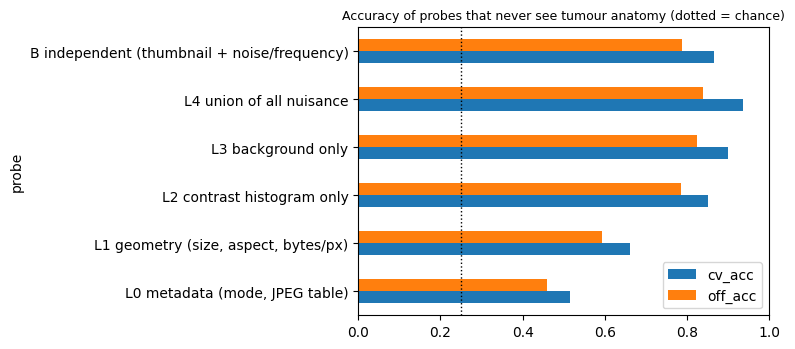

In [4]:
hgb = lambda: HistGradientBoostingClassifier(max_iter=150, random_state=0)
def pfull(clf, X): p = np.full((len(X), K), 1e-4); p[:, clf.classes_] = clf.predict_proba(X); return p
def probe_cv(X):
    P = np.zeros((N, K))
    for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); P[te] = pfull(hgb().fit(X[a], y[a]), X[te])
    return P
probe_off = lambda X: pfull(hgb().fit(X[tr_off], y[tr_off]), X[te_off])
LADDER = {"L0 metadata (mode, JPEG table)": F0, "L1 geometry (size, aspect, bytes/px)": F1, "L2 contrast histogram only": F2, "L3 background only": F3, "L4 union of all nuisance": FU}
PCV, POFF, rows = {}, {}, []; chance = lambda a: (a - 1/K)/(1 - 1/K)
for nm, X in LADDER.items():
    PCV[nm], POFF[nm] = probe_cv(X), probe_off(X); pc_, po_ = PCV[nm].argmax(1), POFF[nm].argmax(1); mcm = MC[te_off]
    rows.append(dict(probe=nm, cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
# family B: independent probes (logistic regression on 12x12 thumbnail, boosting on noise/frequency statistics, averaged). Never used in training any method.
def fitB(Xa, ya):
    lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=400, C=0.05)).fit(Xa[:, F4.shape[1]:], ya); return lr, hgb().fit(Xa[:, :F4.shape[1]], ya)
def predB(mdl, X):
    lr, hg = mdl; p1 = np.full((len(X), K), 1e-4); p1[:, lr.classes_] = lr.predict_proba(X[:, F4.shape[1]:]); p2 = pfull(hg, X[:, :F4.shape[1]]); return (p1 + p2)/2
FB = np.c_[F4, F5]; PCVB = np.zeros((N, K))
for sp, _, _, te in SP0[:NFOLD]: a = np.setdiff1d(np.arange(N), te); PCVB[te] = predB(fitB(FB[a], y[a]), FB[te])
POFFB = predB(fitB(FB[tr_off], y[tr_off]), FB[te_off]); pc_, po_ = PCVB.argmax(1), POFFB.argmax(1); mcm = MC[te_off]
rows.append(dict(probe="B independent (thumbnail + noise/frequency)", cv_acc=(pc_ == y).mean(), off_acc=(po_ == y[te_off]).mean(), off_missing_cell_acc=(po_ == y[te_off])[mcm].mean() if mcm.any() else np.nan, off_missing_pred_notumor=(po_[mcm] == NOTU).mean() if mcm.any() else np.nan))
ladder = pd.DataFrame(rows).set_index("probe").round(3); print(ladder.to_string()); ladder.to_csv(f"{OUT}/table_shortcut_ladder.csv")
fig, ax = plt.subplots(figsize=(8, 3.6)); ladder[["cv_acc", "off_acc"]].plot.barh(ax=ax); ax.axvline(1/K, color="k", ls=":", lw=1); ax.set_xlim(0, 1); ax.set_title("Accuracy of probes that never see tumour anatomy (dotted = chance)", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_ladder.png", dpi=150); plt.show()

## 4. Counter-Shortcut Sets: A (in-family) and B (independent)
**Why:** a counter-shortcut image is one where the true class has probability below 0.10 under the nuisance probes. A model that only follows shortcuts fails there, so accuracy on this set (**CSA**) is closer to "does it read anatomy". **Set B** is built from a different probe family and is the one we trust for claims.

SSF (CV, family A): 0.936 of images solved by nuisance channels alone
CSS A: CV=300, official=210 | CSS B (threshold 0.1): CV=167, official=149 | overlap A and B (CV): 78
CSS B by class: {'meningioma': 91, 'glioma': 57, 'notumor': 10, 'pituitary': 9} | by format: {'RGB|q38|other': 137, 'L|q116|std': 17, 'RGB|q38|std': 12, 'RGB|q116|other': 1}


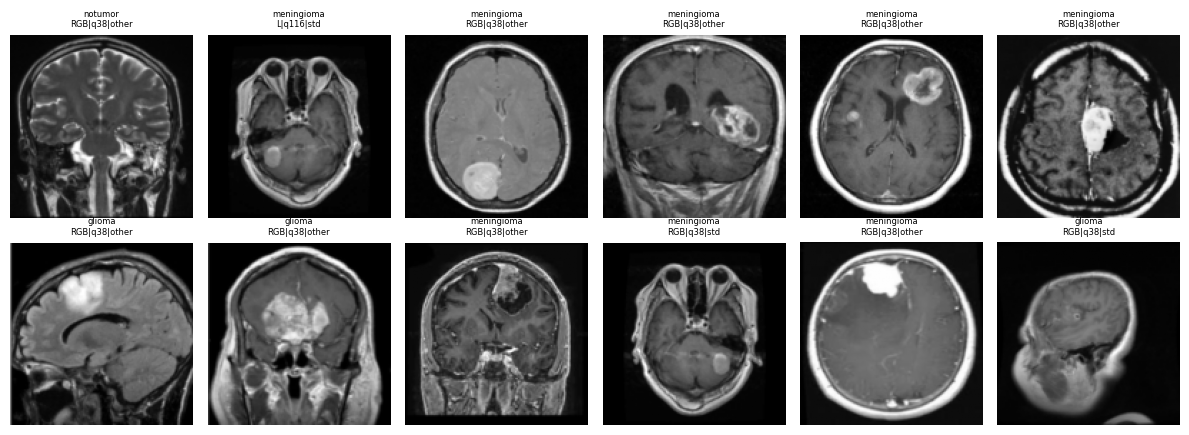

In [5]:
pu = PCV["L4 union of all nuisance"]; CSS = pu[np.arange(N), y] < .10
po = POFF["L4 union of all nuisance"]; CSSOFF = np.zeros(N, bool); CSSOFF[te_off] = po[np.arange(len(te_off)), y[te_off]] < .10
thrB = .10
if (PCVB[np.arange(N), y] < thrB).sum() < 150: thrB = .20
CSS_B = PCVB[np.arange(N), y] < thrB; CSSOFF_B = np.zeros(N, bool); CSSOFF_B[te_off] = POFFB[np.arange(len(te_off)), y[te_off]] < thrB
print(f"SSF (CV, family A): {(pu.argmax(1) == y).mean():.3f} of images solved by nuisance channels alone")
print(f"CSS A: CV={int(CSS.sum())}, official={int(CSSOFF.sum())} | CSS B (threshold {thrB}): CV={int(CSS_B.sum())}, official={int(CSSOFF_B.sum())} | overlap A and B (CV): {int((CSS & CSS_B).sum())}")
print("CSS B by class:", pd.Series(np.array(classes)[y[CSS_B]]).value_counts().to_dict(), "| by format:", pd.Series(df.fg.values[CSS_B]).value_counts().head(4).to_dict())
fig, ax = plt.subplots(2, 6, figsize=(12, 4.4)); ix = np.random.RandomState(0).choice(np.where(CSS_B)[0], 12, replace=False)
for a, i in zip(ax.ravel(), ix): a.imshow(Xr[i], cmap="gray"); a.axis("off"); a.set_title(f"{classes[y[i]]}\n{df.fg[i]}", fontsize=6)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_css_B_examples.png", dpi=140); plt.show()

## 5. Models and the 9 training methods
**Why:** we compare our probe-guided variants with six well-known methods under the same optimiser, epochs, augmentation and validation rule, so differences come from the method only.

| Code | Method | Source |
|---|---|---|
| `erm` | plain training | baseline |
| `groupdro` | worst-group optimisation on class x format groups | Sagawa et al. 2020 |
| `jtt` | train, find mistakes, upweight them x5, retrain | Liu et al. 2021 |
| `dfl` | debiased focal loss with the bias expert | Utama et al. 2020 / Mahabadi et al. 2020 |
| `poe_100` | product-of-experts at full strength | Clark et al. 2019, Cadene et al. 2019 |
| `cfr` | contrast and framing randomisation (augmentation baseline) | domain-randomisation family |
| `poe_050` | **ours**: PoE with half strength, bias expert from the nuisance ladder | this work |
| `ipw` | **ours**: inverse propensity weights from the nuisance probe | this work |
| `ipw_cfr` | **ours**: IPW plus CFR on half of each batch | this work |

Epoch selection (same for all): 0.5 x per-cell accuracy + 0.5 x accuracy on counter-shortcut images of the validation fold.

In [6]:
T0 = torch.empty(Xr.shape, dtype=torch.float16, device=dev)
for i in range(0, N, 500): T0[i:i+500] = torch.as_tensor((Xr[i:i+500].astype(np.float32)/255 - .45)/.225).half().to(dev)
yt_all, ct_all = torch.as_tensor(y).to(dev), torch.as_tensor(cid).to(dev)
def make_backbone(name):
    m = torchvision.models.get_model(name, weights=WEIGHTS[name])
    if name.startswith("resnet"): return nn.Sequential(*list(m.children())[:-2]), m.fc.in_features
    if name.startswith("densenet"): return nn.Sequential(m.features, nn.ReLU()), m.classifier.in_features
    if name.startswith(("efficientnet", "convnext")): return m.features, m.classifier[-1].in_features
    if name.startswith("regnet"): return nn.Sequential(m.stem, m.trunk_output), m.fc.in_features
    raise ValueError(name)
class Net(nn.Module):
    def __init__(s, bb): super().__init__(); s.f, d = make_backbone(bb); s.c = nn.Linear(d, K)
    def fmap(s, x): return s.f(x.float().unsqueeze(1).expand(-1, 3, -1, -1))
    def forward(s, x): return s.c(s.fmap(x).mean((2, 3)))
def aug_base(x):
    if np.random.rand() < .5: x = x.flip(-1)
    return x*(1 + .3*(torch.rand(len(x), 1, 1, device=x.device) - .5))
def cfr_aug(x):          # random contrast curve (mostly monotone) and framing (zoom, aspect, rotation, shift); class-independent
    B, dv = x.shape[0], x.device; u = (x.float()*.225 + .45).clamp(0, 1)
    kn = torch.rand(B, 6, device=dv); kn = torch.where(torch.rand(B, 1, device=dv) > .15, torch.sort(kn, 1).values, kn)
    pos = u*5; i0 = pos.floor().clamp(0, 4).long(); fr = pos - i0.float()
    k0 = torch.gather(kn, 1, i0.view(B, -1)).view_as(u); k1 = torch.gather(kn, 1, (i0 + 1).view(B, -1)).view_as(u); out = k0 + (k1 - k0)*fr
    ang = (torch.rand(B, device=dv) - .5)*.42; zm = .85 + .35*torch.rand(B, device=dv); asp = .85 + .3*torch.rand(B, device=dv); th = torch.zeros(B, 2, 3, device=dv)
    th[:, 0, 0] = zm*asp*torch.cos(ang); th[:, 0, 1] = -zm*torch.sin(ang); th[:, 1, 0] = zm*asp*torch.sin(ang); th[:, 1, 1] = zm*torch.cos(ang); th[:, :, 2] = (torch.rand(B, 2, device=dv) - .5)*.2
    out = F.grid_sample(out.unsqueeze(1), F.affine_grid(th, (B, 1, IMG, IMG), align_corners=False), padding_mode="border", align_corners=False).squeeze(1)
    out = (out + .03*torch.randn_like(out)).clamp(0, 1)
    if np.random.rand() < .5: out = out.flip(-1)
    return (out - .45)/.225
@torch.no_grad()
def predx(m, x):
    m.eval(); out = []
    for i in range(0, len(x), 256):
        with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): out.append(F.softmax(m(x[i:i+256]).float(), 1).cpu())
    return torch.cat(out).numpy()
probs = lambda m, X, idx: predx(m, X[torch.as_tensor(idx).to(dev)])
def vscore(m, va):
    p = probs(m, T0, va).argmax(1); c = p == y[va]; a = np.bincount(cid[va], weights=c, minlength=NC); n = np.bincount(cid[va], minlength=NC); ok = n >= 3
    s = CSS[va]; return .5*(a[ok]/n[ok]).mean() + .5*(c[s].mean() if s.any() else (a[ok]/n[ok]).mean())
def bias_logp(tr, seed):                      # cross-fitted family-A bias expert: out-of-fold log-probabilities for every training image
    lb = np.zeros((N, K), np.float32)
    for a, b in StratifiedGroupKFold(4, shuffle=True, random_state=seed).split(tr, y[tr], df.grp.values[tr]): lb[tr[b]] = np.log(np.clip(pfull(hgb().fit(FU[tr[a]], y[tr[a]]), FU[tr[b]]), 1e-3, 1))
    return torch.as_tensor(lb).to(dev)
def fit(bb, method, tr, va, seed, LB=None, SW=None, epochs=None):
    n_ep = epochs or EPOCHS; torch.manual_seed(seed); np.random.seed(seed); m = Net(bb).to(dev)
    opt = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4); sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=LR, total_steps=n_ep*int(np.ceil(len(tr)/BATCH)))
    scaler = torch.cuda.amp.GradScaler(enabled=(dev == "cuda")); best = -1; q = torch.ones(NC, device=dev)/NC
    lprior = torch.log(torch.as_tensor(np.bincount(y[tr], minlength=K)/len(tr) + 1e-9, dtype=torch.float32)).to(dev); alpha = {"poe_050": .5, "poe_100": 1.0}.get(method, 0.0)
    for ep in range(n_ep):
        m.train(); perm = np.random.permutation(tr)
        for b in range(0, len(perm), BATCH):
            ix = torch.as_tensor(perm[b:b+BATCH]).to(dev)
            if len(ix) < 4: sched.step(); continue
            x = aug_base(T0[ix])
            if method in ("cfr", "ipw_cfr"): x = torch.where(torch.rand(len(ix), 1, 1, device=dev) < .5, cfr_aug(T0[ix]).to(x.dtype), x)
            with torch.autocast("cuda", dtype=torch.float16, enabled=(dev == "cuda")): lo = m(x)
            lo = lo.float(); yy = yt_all[ix]
            if alpha: lo = lo + alpha*LB[ix]
            l = F.cross_entropy(lo, yy, reduction="none")
            if method in ("ipw", "ipw_cfr"): w = torch.exp(lprior[yy] - LB[ix, yy]).clamp(.2, 5); l = l*(w/w.mean())
            if method == "dfl": l = l*(1 - torch.exp(LB[ix, yy])).pow(DFL_GAMMA)
            if SW is not None: l = l*SW[ix]
            if method == "groupdro":
                g = ct_all[ix]; gc = torch.bincount(g, minlength=NC).float(); gl = torch.zeros(NC, device=dev).scatter_add(0, g, l)/gc.clamp(min=1)
                q = q*torch.exp(DRO_ETA*gl.detach()*(gc > 0)); q = q/q.sum(); loss = (q*gl).sum()
            else: loss = l.mean()
            opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        a = vscore(m, va)
        if a >= best: best, st = a, {k_: v_.clone() for k_, v_ in m.state_dict().items()}
    m.load_state_dict(st); return m, best
def fit_any(bb, method, tr, va, seed, LB=None):
    if method == "jtt":                                      # stage 1: short ERM; stage 2: retrain with its training mistakes upweighted
        m1, _ = fit(bb, "erm", tr, va, seed, epochs=EPOCHS_J); wrong = tr[probs(m1, T0, tr).argmax(1) != y[tr]]; del m1
        sw = torch.ones(N, device=dev); sw[torch.as_tensor(wrong).to(dev)] = JTT_LAMBDA; return fit(bb, "erm", tr, va, seed, SW=sw)
    return fit(bb, method, tr, va, seed, LB)

## 6. Experiments (resumable)
**Why:** 9 methods x (5 CV folds + the official Training-to-Testing split) x seeds x architectures. Every run is saved, so if Kaggle stops you can start again and it continues.

In [7]:
LIT = ["erm", "groupdro", "jtt", "dfl", "poe_100", "cfr"]; OURS = ["poe_050", "ipw", "ipw_cfr"]; METHODS = LIT + OURS; BASE = "erm"
NEEDS_LB = ("poe_050", "poe_100", "ipw", "ipw_cfr", "dfl")
LABEL = {"erm": "ERM", "groupdro": "GroupDRO", "jtt": "JTT", "dfl": "Debiased focal", "poe_100": "PoE full", "cfr": "CFR augment", "poe_050": "OURS PoE-0.5", "ipw": "OURS IPW", "ipw_cfr": "OURS IPW+CFR"}
def run_grid(bb, seeds):
    pbar = tqdm(total=len(seeds)*(NFOLD + 1)*len(METHODS), desc=bb)
    for seed in seeds:
        for sp, tr, va, te in make_splits(seed):
            LB = bias_logp(tr, seed)
            for mt in METHODS:
                f = f"{RUNS}/{bb}__{mt}__s{seed}__{sp}.npz"
                if os.path.exists(f): pbar.update(1); continue
                m, vs = fit_any(bb, mt, tr, va, seed, LB); p = probs(m, T0, te); pv = probs(m, T0, va).argmax(1); sv = CSS[va]
                if sp in ("f0", "off") and seed == seeds[0]: torch.save(m.state_dict(), f"{MODELS}/{bb}__{mt}__{sp}.pt")
                np.savez(f, te=te, pred=p.argmax(1), conf=p.max(1), prob=p.astype(np.float16), vscore=vs, v_acc=(pv == y[va]).mean(), v_csa=(pv[sv] == y[va][sv]).mean() if sv.any() else np.nan)
                del m; torch.cuda.empty_cache() if dev == "cuda" else None; pbar.update(1)
for bb in ARCHS: run_grid(bb, seeds_of[bb])

convnext_tiny:   0%|          | 0/162 [00:00<?, ?it/s]

resnet50:   0%|          | 0/54 [00:00<?, ?it/s]

efficientnet_b0:   0%|          | 0/54 [00:00<?, ?it/s]

## 7. Results: every method, every architecture

In [8]:
def load_runs():
    raw = {}
    for f in sorted(glob.glob(f"{RUNS}/*.npz")):
        if os.path.basename(f).startswith("fs__"): continue
        bb, mt, s, sp = os.path.basename(f)[:-4].split("__"); z = np.load(f); raw.setdefault((bb, mt, int(s[1:])), {})[sp] = {a: z[a] for a in z.files}
    R, OFF = {}, {}
    for key, d in raw.items():
        if all(f"f{k}" in d for k in range(NFOLD)):
            e = dict(runs=[d[f"f{k}"] for k in range(NFOLD)], pred=np.zeros(N, np.int64), conf=np.zeros(N, np.float32))
            for r in e["runs"]: e["pred"][r["te"]] = r["pred"]; e["conf"][r["te"]] = r["conf"]
            R[key] = e
        if "off" in d: OFF[key] = d["off"]
    return R, OFF
R, OFF = load_runs(); print(len(R), "complete CV combinations |", len(OFF), "official-split runs")
def ece(conf, cor, nb=15):
    e = 0; bins = np.linspace(0, 1, nb+1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        s = (conf > lo) & (conf <= hi); e += s.mean()*abs(cor[s].mean() - conf[s].mean()) if s.any() else 0
    return e
def metrics_on(idx, pred, conf, cssA, cssB, min_cell):
    yy = y[idx]; c = pred == yy; tum = yy != NOTU; r = dict(acc=c.mean(), macro_f1=f1_score(yy, pred, average="macro"), ece=ece(conf, c))
    sA, sB = cssA[idx], cssB[idx]; r["csa"] = c[sA].mean() if sA.any() else np.nan; r["csa_B"] = c[sB].mean() if sB.any() else np.nan
    mm = MC[idx]; r["missing_cell_acc"] = c[mm].mean() if mm.any() else np.nan; r["missing_cell_detect"] = (pred[mm] != NOTU).mean() if mm.any() else np.nan
    r["sens"] = (pred[tum] != NOTU).mean() if tum.any() else np.nan; r["spec"] = (pred[~tum] == NOTU).mean() if (~tum).any() else np.nan
    a = np.bincount(cid[idx], weights=c, minlength=NC); n = np.bincount(cid[idx], minlength=NC); ok = n >= min_cell; r["worst_cell"] = (a[ok]/n[ok]).min() if ok.any() else np.nan; return r
cols = ["acc", "macro_f1", "ece", "csa", "csa_B", "missing_cell_acc", "missing_cell_detect", "sens", "spec", "worst_cell"]
per = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(np.arange(N), e["pred"], e["conf"], CSS, CSS_B, MIN_CELL)) for (bb, mt, s), e in R.items()]); per.to_csv(f"{OUT}/per_seed_cv.csv", index=False)
off = pd.DataFrame([dict(arch=bb, method=mt, seed=s, **metrics_on(r["te"], r["pred"], r["conf"], CSSOFF, CSSOFF_B, 10)) for (bb, mt, s), r in OFF.items()]); off.to_csv(f"{OUT}/per_seed_off.csv", index=False)
def show(d, title, fn):
    g = d.groupby(["arch", "method"]); t = (g[cols].mean().round(3).astype(str) + " +/- " + g[cols].std().fillna(0).round(3).astype(str)).reindex(pd.MultiIndex.from_product([ARCHS, METHODS], names=["arch", "method"])).dropna(how="all")
    print(title); print(t.to_string()); t.to_csv(f"{OUT}/{fn}.csv")
show(off, "OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, missing_cell_detect = tumour detected on the never-seen cell", "table_official")
show(per, "\nCROSS-VALIDATION (pooled out-of-fold, duplicate-safe)", "table_cv")

45 complete CV combinations | 45 official-split runs
OFFICIAL SPLIT (train Training, test Testing). csa = in-family counter-shortcut, csa_B = INDEPENDENT counter-shortcut, missing_cell_detect = tumour detected on the never-seen cell
                                      acc         macro_f1              ece              csa            csa_B missing_cell_acc missing_cell_detect             sens             spec       worst_cell
arch            method                                                                                                                                                                               
convnext_tiny   erm        0.924 +/- 0.02  0.922 +/- 0.021  0.051 +/- 0.005  0.543 +/- 0.069  0.485 +/- 0.079  0.083 +/- 0.046      0.496 +/- 0.05  0.951 +/- 0.005  0.981 +/- 0.022  0.083 +/- 0.046
                groupdro  0.938 +/- 0.003  0.936 +/- 0.003  0.047 +/- 0.006   0.603 +/- 0.04  0.541 +/- 0.045   0.083 +/- 0.04     0.618 +/- 0.139  0.966 +/- 0.013  0.993 +/

## 7b. The pre-set selection rule for our final variant
**Why:** if we picked the best variant by looking at test numbers, a reviewer could say we cherry-picked. So the rule is fixed in advance and uses **validation folds of cross-validation only** (never the official test, never set B):
*Among our three variants, keep those whose mean validation accuracy is within 1.5 points of ERM; choose the one with the highest mean validation counter-shortcut accuracy (set A). If none qualifies, choose the highest validation accuracy.*

In [9]:
vrows = [dict(method=mt, seed=s, v_acc=float(np.mean([r["v_acc"] for r in e["runs"]])), v_csa=float(np.nanmean([r["v_csa"] for r in e["runs"]]))) for (bb, mt, s), e in R.items() if bb == ARCH1]
vt = pd.DataFrame(vrows).groupby("method")[["v_acc", "v_csa"]].mean().reindex(METHODS).round(4); print("validation numbers used by the rule (primary architecture):"); print(vt.to_string()); vt.to_csv(f"{OUT}/table_selection_validation.csv")
elig = [m for m in OURS if vt.loc[m, "v_acc"] >= vt.loc["erm", "v_acc"] - 0.015]
FINAL = max(elig, key=lambda m: vt.loc[m, "v_csa"]) if elig else max(OURS, key=lambda m: vt.loc[m, "v_acc"])
print("eligible variants:", elig, "\nFINAL (chosen before looking at any test result):", FINAL, "=", LABEL[FINAL])

validation numbers used by the rule (primary architecture):
           v_acc   v_csa
method                  
erm       0.9732  0.8016
groupdro  0.9580  0.7799
jtt       0.9699  0.7936
dfl       0.7607  0.7928
poe_100   0.8699  0.7965
cfr       0.9695  0.7943
poe_050   0.9640  0.8309
ipw       0.9610  0.8332
ipw_cfr   0.9390  0.8324
eligible variants: ['poe_050', 'ipw'] 
FINAL (chosen before looking at any test result): ipw = OURS IPW


## 8. Statistics: duplicate-aware bootstrap, FINAL against every other method
**Why:** images in the same near-duplicate group are not independent, so we resample groups, not images. We report mean and 95% intervals, and for each metric the difference between our FINAL variant and each other method (P>0 means the share of bootstrap draws in which FINAL is better).

In [10]:
ug, gi = np.unique(df.grp.values, return_inverse=True); NG = len(ug); B = 1000; IX = np.random.RandomState(0).randint(0, NG, (B, NG))
def boot_ratio(v, mask):
    num = np.bincount(gi, weights=v*mask, minlength=NG); den = np.bincount(gi, weights=mask, minlength=NG); return num[IX].sum(1)/np.maximum(den[IX].sum(1), 1e-9)
den_m = np.zeros((NG, NC)); np.add.at(den_m, (gi, cid), 1.0)
def boot_worst(v):
    num = np.zeros((NG, NC)); np.add.at(num, (gi, cid), v); out = np.zeros(B)
    for b in range(B): n_, d_ = num[IX[b]].sum(0), den_m[IX[b]].sum(0); ok = okcell & (d_ > 0); out[b] = (n_[ok]/d_[ok]).min()
    return out
ONE, OFFM = np.ones(N), np.zeros(N); OFFM[te_off] = 1; MCf = MC.astype(float)
cvspec = {"acc": ONE, "csa_B": CSS_B.astype(float), "missing_cell_acc": MCf}
offspec = {"off_acc": OFFM, "off_csa": CSSOFF.astype(float), "off_csa_B": CSSOFF_B.astype(float), "off_missing_cell_acc": OFFM*MCf}
bres = {}
for bb in ARCHS:
    for mt in METHODS:
        ss = [s for s in seeds_of[bb] if (bb, mt, s) in R]; so = [s for s in seeds_of[bb] if (bb, mt, s) in OFF]
        if not ss: continue
        cv_c = np.mean([(R[(bb, mt, s)]["pred"] == y) for s in ss], 0).astype(float); d = {k: boot_ratio(cv_c, mk) for k, mk in cvspec.items()}; d["worst_cell"] = boot_worst(cv_c)
        if so:
            of_c, of_d = np.zeros(N), np.zeros(N)
            for s in so:
                te = OFF[(bb, mt, s)]["te"]; pr = OFF[(bb, mt, s)]["pred"]; of_c[te] += (pr == y[te])/len(so); of_d[te] += (pr != NOTU)/len(so)
            d.update({k: boot_ratio(of_c, mk) for k, mk in offspec.items()}); d["off_missing_detect"] = boot_ratio(of_d, OFFM*MCf)
        bres[(bb, mt)] = d
ci = lambda a: f"{a.mean():.3f} [{np.percentile(a,2.5):.3f},{np.percentile(a,97.5):.3f}]"
ci_df = pd.DataFrame([dict(arch=bb, method=LABEL[mt], **{k: ci(v) for k, v in d.items()}) for (bb, mt), d in bres.items()]); print(ci_df.to_string()); ci_df.to_csv(f"{OUT}/table_ci.csv", index=False)
KEYM = ["off_acc", "off_csa_B", "off_missing_cell_acc", "off_missing_detect", "acc", "csa_B"]; rows = []
for bb in ARCHS:
    if (bb, FINAL) not in bres: continue
    for mt in METHODS:
        if mt == FINAL or (bb, mt) not in bres: continue
        r = dict(arch=bb, vs=LABEL[mt])
        for k in KEYM:
            if k in bres[(bb, FINAL)] and k in bres[(bb, mt)]: dd = bres[(bb, FINAL)][k] - bres[(bb, mt)][k]; r[k] = f"{dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}] P>0={float((dd > 0).mean()):.2f}"
        rows.append(r)
vs_df = pd.DataFrame(rows); print(f"\nFINAL ({LABEL[FINAL]}) minus each other method (positive = FINAL better):"); print(vs_df.to_string()); vs_df.to_csv(f"{OUT}/table_final_vs_all.csv", index=False)

               arch          method                  acc                csa_B     missing_cell_acc           worst_cell              off_acc              off_csa            off_csa_B off_missing_cell_acc   off_missing_detect
0     convnext_tiny             ERM  0.971 [0.967,0.975]  0.721 [0.647,0.797]  0.569 [0.464,0.672]  0.568 [0.462,0.671]  0.924 [0.910,0.938]  0.544 [0.474,0.607]  0.487 [0.411,0.565]  0.085 [0.034,0.143]  0.494 [0.392,0.611]
1     convnext_tiny        GroupDRO  0.958 [0.953,0.963]  0.763 [0.691,0.829]  0.679 [0.587,0.763]  0.665 [0.573,0.752]  0.939 [0.924,0.951]  0.605 [0.531,0.674]  0.544 [0.457,0.629]  0.085 [0.035,0.143]  0.618 [0.504,0.732]
2     convnext_tiny             JTT  0.969 [0.964,0.973]  0.753 [0.679,0.823]  0.656 [0.561,0.752]  0.653 [0.556,0.744]  0.926 [0.910,0.939]  0.515 [0.444,0.584]  0.437 [0.358,0.522]  0.035 [0.005,0.073]  0.467 [0.355,0.581]
3     convnext_tiny  Debiased focal  0.759 [0.749,0.771]  0.757 [0.687,0.832]  0.674 [0.564,0.779]  

## 9. The showdown: who ranks first? (printed honestly)
**Why:** one table that ranks all 9 methods on the metrics that matter (official accuracy, both counter-shortcut sets, the unseen cell, tumour detection on it, calibration, CV accuracy). The verdict below is generated from the numbers, so it cannot say more than the data say.


[convnext_tiny] mean rank over 8 metrics (1 = best):
                mean_rank  first_places
OURS PoE-0.5         3.12             1
OURS IPW+CFR         3.62             1
PoE full             3.88             3
CFR augment          4.25             1
OURS IPW             4.75             0
Debiased focal       5.25             1
GroupDRO             5.62             0
ERM                  6.75             1
JTT                  7.38             0

[resnet50] mean rank over 8 metrics (1 = best):
                mean_rank  first_places
OURS IPW+CFR         2.88             2
OURS IPW             3.88             0
PoE full             4.00             3
JTT                  4.12             1
OURS PoE-0.5         4.50             0
CFR augment          5.38             0
Debiased focal       6.00             1
ERM                  6.38             1
GroupDRO             7.75             0

[efficientnet_b0] mean rank over 8 metrics (1 = best):
                mean_rank  first_places
O

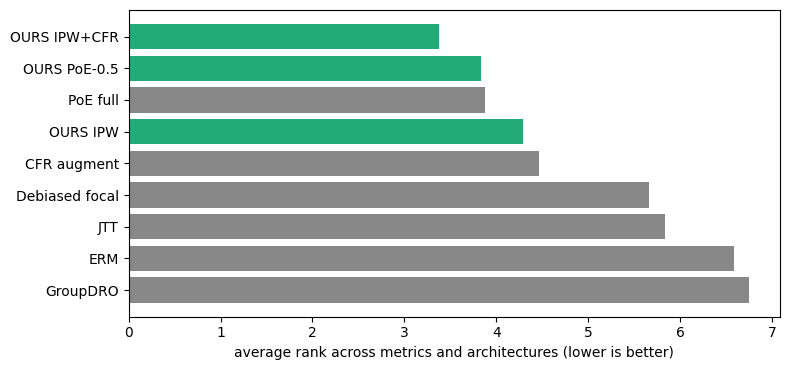


VERDICT (auto-generated):
- Best average rank: OURS IPW+CFR. Our final variant (OURS IPW) is #4 of 9. Best literature method: PoE full (average rank 3.88 vs ours 4.29).
- convnext_tiny: independent counter-shortcut accuracy gain over ERM = +0.102 [+0.054,+0.161]; clean official accuracy change = +0.008
- resnet50: independent counter-shortcut accuracy gain over ERM = +0.168 [+0.098,+0.245]; clean official accuracy change = +0.008
- efficientnet_b0: independent counter-shortcut accuracy gain over ERM = +0.213 [+0.136,+0.290]; clean official accuracy change = +0.046
- Write the paper according to this verdict. If ours is not first, say which method wins and on which metric, and present ours as the best accuracy-reliability trade-off only if the numbers show it.


In [11]:
RK = {}
for bb in ARCHS:
    d = off[off.arch == bb].groupby("method")[["acc", "csa", "csa_B", "missing_cell_acc", "missing_cell_detect", "ece"]].mean().add_prefix("off_").join(per[per.arch == bb].groupby("method")[["acc", "csa_B"]].mean().add_prefix("cv_")).reindex(METHODS)
    rk = d.rank(ascending=False, method="min"); rk["off_ece"] = d["off_ece"].rank(ascending=True, method="min")
    RK[bb] = pd.DataFrame(dict(mean_rank=rk.mean(1), first_places=(rk == 1).sum(1))).round(2); RK[bb].index = [LABEL[m] for m in RK[bb].index]
    print(f"\n[{bb}] mean rank over {rk.shape[1]} metrics (1 = best):"); print(RK[bb].sort_values("mean_rank").to_string())
allrk = pd.concat([RK[b]["mean_rank"].rename(b) for b in ARCHS], axis=1); allrk["average"] = allrk.mean(1); allrk = allrk.sort_values("average"); allrk.to_csv(f"{OUT}/table_showdown_rank.csv")
fig, ax = plt.subplots(figsize=(8, 3.8)); ax.barh(allrk.index[::-1], allrk["average"][::-1], color=["#2a7" if "OURS" in i else "#888" for i in allrk.index[::-1]]); ax.set_xlabel("average rank across metrics and architectures (lower is better)")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_showdown_rank.png", dpi=150); plt.show()
best = allrk.index[0]; ours_lab = LABEL[FINAL]; best_lit = [i for i in allrk.index if "OURS" not in i][0]
print("\nVERDICT (auto-generated):")
print(f"- Best average rank: {best}. Our final variant ({ours_lab}) is #{list(allrk.index).index(ours_lab) + 1} of {len(allrk)}. Best literature method: {best_lit} (average rank {allrk.loc[best_lit, 'average']:.2f} vs ours {allrk.loc[ours_lab, 'average']:.2f}).")
for bb in ARCHS:
    if (bb, FINAL) in bres and (bb, "erm") in bres:
        dd = bres[(bb, FINAL)]["off_csa_B"] - bres[(bb, "erm")]["off_csa_B"]; print(f"- {bb}: independent counter-shortcut accuracy gain over ERM = {dd.mean():+.3f} [{np.percentile(dd,2.5):+.3f},{np.percentile(dd,97.5):+.3f}]; clean official accuracy change = {(bres[(bb, FINAL)]['off_acc'] - bres[(bb, 'erm')]['off_acc']).mean():+.3f}")
print("- Write the paper according to this verdict. If ours is not first, say which method wins and on which metric, and present ours as the best accuracy-reliability trade-off only if the numbers show it.")

## 9b. Are deep-model errors explained by the shortcut probe? (official split, unseen cell)
**Why:** if a model's mistakes match the nuisance probe's mistakes, it is probably following the same shortcut. We also print what each method predicts on the never-seen cell, to see whether errors move from dangerous (called notumor) to milder (wrong tumour type).

In [12]:
pu_off = POFF["L4 union of all nuisance"].argmax(1); yo = y[te_off]; mcm = MC[te_off]; rows = []; conf_tab = {}
for (bb, mt, s), r in OFF.items():
    if s != seeds_of[bb][0] or r["te"].shape != te_off.shape: continue
    wrong = r["pred"] != yo; rows.append(dict(arch=bb, method=mt, agree_with_probe=(r["pred"] == pu_off).mean(), share_of_errors_probe_also_makes_same_error=(pu_off[wrong] == r["pred"][wrong]).mean(),
                                              missing_cell_agree_with_probe=(r["pred"][mcm] == pu_off[mcm]).mean() if mcm.any() else np.nan))
    if mcm.any(): conf_tab[f"{bb}|{mt}"] = np.bincount(r["pred"][mcm], minlength=K)
if mcm.any(): conf_tab["nuisance probe (union)"] = np.bincount(pu_off[mcm], minlength=K)
ex = pd.DataFrame(rows).set_index(["arch", "method"]).round(3); print(ex.to_string()); ex.to_csv(f"{OUT}/table_explained_by_shortcut.csv")
if mcm.any():
    ct_ = pd.DataFrame(conf_tab, index=classes).T; ct_.insert(0, "n", int(mcm.sum())); print("\nPredictions on the never-seen cell (true class =", classes[int(np.bincount(y[te_off][mcm]).argmax())], "):"); print(ct_.to_string()); ct_.to_csv(f"{OUT}/table_missing_cell_predictions.csv")

                          agree_with_probe  share_of_errors_probe_also_makes_same_error  missing_cell_agree_with_probe
arch            method                                                                                                
convnext_tiny   cfr                  0.856                                        0.385                          0.316
                dfl                  0.472                                        0.011                          0.053
                erm                  0.866                                        0.493                          0.513
                groupdro             0.854                                        0.344                          0.263
                ipw                  0.833                                        0.172                          0.145
                ipw_cfr              0.823                                        0.142                          0.132
                jtt                  0.871      

## 10. The shortcut dial (no retraining)
**Why:** a PoE model learned `f(x)` while the bias expert supplied the shortcut. At test time we can add the shortcut back with strength `beta`: `log p_f + beta * log p_bias`. One model then gives a whole accuracy versus reliability curve.

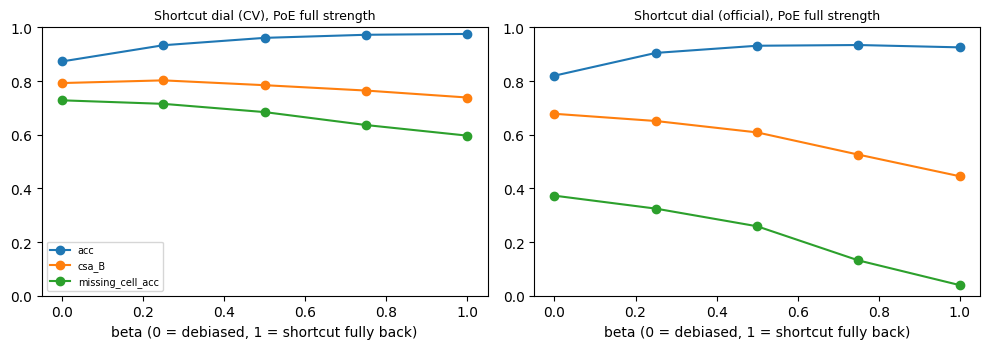

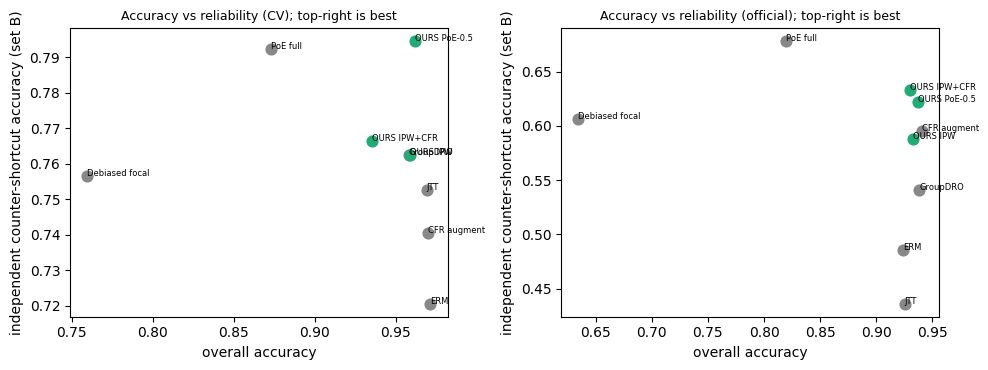

In [13]:
BETAS = [0, .25, .5, .75, 1.0]; L4 = "L4 union of all nuisance"; rows = []
lb_cv, lb_off = np.log(np.clip(PCV[L4], 1e-3, 1)), np.log(np.clip(POFF[L4], 1e-3, 1))
for (bb, mt, s), e in R.items():
    if not mt.startswith("poe"): continue
    pm = np.zeros((N, K), np.float32)
    for r in e["runs"]: pm[r["te"]] = r["prob"].astype(np.float32)
    lp = np.log(np.clip(pm, 1e-6, 1))
    for beta in BETAS:
        c = (lp + beta*lb_cv).argmax(1) == y; rows.append(dict(arch=bb, method=mt, seed=s, protocol="CV", beta=beta, acc=c.mean(), csa_B=c[CSS_B].mean(), missing_cell_acc=c[MC].mean()))
for (bb, mt, s), r in OFF.items():
    if not mt.startswith("poe") or r["te"].shape != te_off.shape: continue
    lp = np.log(np.clip(r["prob"].astype(np.float32), 1e-6, 1)); yo = y[te_off]
    for beta in BETAS:
        c = (lp + beta*lb_off).argmax(1) == yo; rows.append(dict(arch=bb, method=mt, seed=s, protocol="official", beta=beta, acc=c.mean(), csa_B=c[CSSOFF_B[te_off]].mean(), missing_cell_acc=c[MC[te_off]].mean()))
dial = pd.DataFrame(rows)
if len(dial):
    dg = dial.groupby(["arch", "method", "protocol", "beta"])[["acc", "csa_B", "missing_cell_acc"]].mean().round(3); dg.to_csv(f"{OUT}/table_shortcut_dial.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for a, pr in zip(ax, ["CV", "official"]):
        d = dial[(dial.arch == ARCH1) & (dial.method == "poe_100") & (dial.protocol == pr)].groupby("beta")[["acc", "csa_B", "missing_cell_acc"]].mean()
        for col in d: a.plot(d.index, d[col], marker="o", label=col)
        a.set_title(f"Shortcut dial ({pr}), PoE full strength", fontsize=9); a.set_xlabel("beta (0 = debiased, 1 = shortcut fully back)"); a.set_ylim(0, 1)
    ax[0].legend(fontsize=7); plt.tight_layout(); plt.savefig(f"{OUT}/fig_shortcut_dial.png", dpi=150); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
for a, (nm, d) in zip(ax, [("CV", per), ("official", off)]):
    gm = d[d.arch == ARCH1].groupby("method")[["acc", "csa_B"]].mean()
    for mt, r in gm.iterrows(): a.scatter(r.acc, r.csa_B, s=60, color="#2a7" if mt in OURS else "#888"); a.annotate(LABEL[mt], (r.acc, r.csa_B), fontsize=6)
    a.set_xlabel("overall accuracy"); a.set_ylabel("independent counter-shortcut accuracy (set B)"); a.set_title(f"Accuracy vs reliability ({nm}); top-right is best", fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_tradeoff.png", dpi=150); plt.show()

## 11. Few-shot recovery on the never-seen cell: ERM vs our FINAL variant
**Why:** it answers a practical question: how many images from the new scanner repair the failure, and does our method need fewer?

cell: glio|RGB|q38|other | shot pool 38 | held-out eval 38 | rest of test 1421
          acc_cell        acc_rest        pred_notumor       
              mean    std     mean    std         mean    std
method k                                                     
erm    0     0.053  0.026    0.969  0.022        0.579  0.070
       4     0.377  0.132    0.981  0.004        0.298  0.066
       8     0.342  0.254    0.954  0.022        0.377  0.106
       16    0.456  0.055    0.967  0.013        0.246  0.055
       32    0.746  0.080    0.952  0.015        0.158  0.026
ipw    0     0.184  0.046    0.973  0.004        0.254  0.080
       4     0.149  0.066    0.963  0.027        0.368  0.070
       8     0.316  0.070    0.965  0.008        0.246  0.085
       16    0.447  0.095    0.966  0.007        0.167  0.015
       32    0.632  0.121    0.951  0.004        0.149  0.092


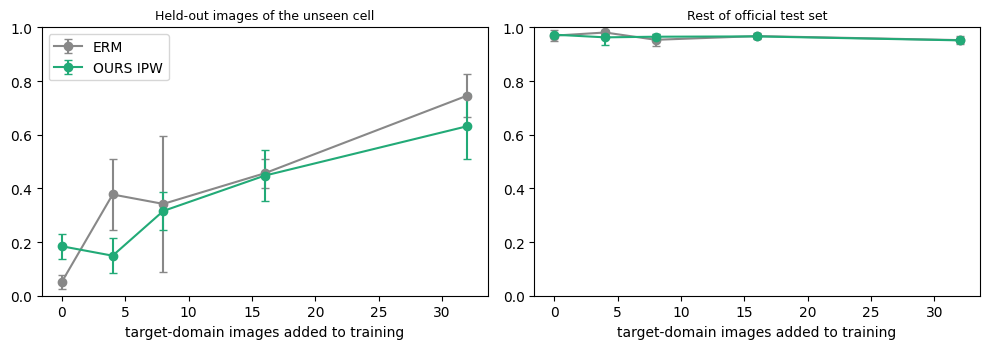

In [14]:
if len(miss):
    mcell = miss[int(np.argmax([ten[c] for c in miss]))]; idx_mc = np.where(cid == mcell)[0]; idx_mc = idx_mc[np.random.RandomState(123).permutation(len(idx_mc))]
    pool, evald = idx_mc[:len(idx_mc)//2], idx_mc[len(idx_mc)//2:]; rest = np.setdiff1d(te_off, idx_mc); print("cell:", cell_names[mcell], "| shot pool", len(pool), "| held-out eval", len(evald), "| rest of test", len(rest))
    for seed in FS_SEEDS:
        sp, tr, va, te = make_splits(seed)[5]
        for mt in (BASE, FINAL):
            for k in KS:
                f = f"{RUNS}/fs__{ARCH1}__{mt}__s{seed}__k{k}.npz"
                if os.path.exists(f): continue
                trk = np.r_[tr, np.repeat(pool[:k], 4)].astype(int) if k else tr
                LB = bias_logp(np.unique(trk), seed) if mt in NEEDS_LB else None
                m, _ = fit_any(ARCH1, mt, trk, va, seed, LB); pe, pr = probs(m, T0, evald).argmax(1), probs(m, T0, rest).argmax(1)
                np.savez(f, acc_cell=(pe == y[evald]).mean(), acc_rest=(pr == y[rest]).mean(), pnot=(pe == NOTU).mean()); del m; torch.cuda.empty_cache() if dev == "cuda" else None
    rows = []
    for f in glob.glob(f"{RUNS}/fs__*.npz"):
        _, bb, mt, s, k = os.path.basename(f)[:-4].split("__"); z = np.load(f); rows.append(dict(method=mt, seed=int(s[1:]), k=int(k[1:]), acc_cell=float(z["acc_cell"]), acc_rest=float(z["acc_rest"]), pred_notumor=float(z["pnot"])))
    fs = pd.DataFrame(rows); fsg = fs.groupby(["method", "k"])[["acc_cell", "acc_rest", "pred_notumor"]].agg(["mean", "std"]).round(3); print(fsg.to_string()); fsg.to_csv(f"{OUT}/table_fewshot.csv")
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for mt, c in ((BASE, "#888"), (FINAL, "#2a7")):
        d = fs[fs.method == mt].groupby("k")
        for a, col, t in zip(ax, ["acc_cell", "acc_rest"], ["Held-out images of the unseen cell", "Rest of official test set"]):
            mu, sd = d[col].mean(), d[col].std().fillna(0); a.errorbar(mu.index, mu, yerr=sd, marker="o", color=c, label=LABEL[mt], capsize=3); a.set_title(t, fontsize=9); a.set_xlabel("target-domain images added to training"); a.set_ylim(0, 1)
    ax[0].legend(); plt.tight_layout(); plt.savefig(f"{OUT}/fig_fewshot_recovery.png", dpi=150); plt.show()
else: print("No missing cell found in this data subset.")

## 12. External validation (needs one more dataset)
**Why:** a journal reviewer will ask whether the gains hold on data from another source. Add any other public brain MRI dataset as a Kaggle input, with **one folder per class** (names such as glioma, meningioma, pituitary, notumor, or a binary yes/no, tumor/normal) and set `EXT_ROOT`. Models trained on the official Training split are tested with no retraining. For binary datasets only tumour detection (sensitivity, specificity) is reported. Check the dataset license first.

In [15]:
if EXT_ROOT and os.path.isdir(EXT_ROOT):
    def lab_of(n):
        n = n.lower()
        for k in ("glioma", "meningioma", "pituitary"):
            if k in n and k in classes: return classes.index(k)
        if any(t in n for t in ("notumor", "no_tumor", "no tumor", "no_tumour", "normal", "healthy", "negative")) or n in ("no", "non"): return NOTU
        if any(t in n for t in ("tumor", "tumour", "yes", "positive", "pred")): return -1                 # tumour of unspecified type
        return None
    items = [(f, lab_of(os.path.basename(d.rstrip("/")))) for d in glob.glob(f"{EXT_ROOT}/**/", recursive=True) for f in glob.glob(d + "*") if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    items = [(f, c) for f, c in items if c is not None]; ey = np.array([c for _, c in items]); print(len(items), "external images | tumour:", int((ey != NOTU).sum()), "| no tumour:", int((ey == NOTU).sum()))
    def std_from(f):
        with Image.open(f) as im: return rs(np.asarray(im.convert("L").resize((S, S), Image.BILINEAR)), Image.BILINEAR)
    ET = torch.as_tensor(((np.stack([std_from(f) for f, _ in tqdm(items)]).astype(np.float32)/255 - .45)/.225)).half().to(dev); rows = []
    for bb in ARCHS:
        for mt in METHODS:
            pth = f"{MODELS}/{bb}__{mt}__off.pt"
            if not os.path.exists(pth): continue
            m = Net(bb).to(dev); m.load_state_dict(torch.load(pth)); pr_ = predx(m, ET).argmax(1); tm = ey != NOTU; spc = ey >= 0
            rows.append(dict(arch=bb, method=LABEL[mt], det_sensitivity=(pr_[tm] != NOTU).mean(), det_specificity=(pr_[~tm] == NOTU).mean(), acc_4class=(pr_[spc] == ey[spc]).mean() if spc.any() else np.nan))
    ext = pd.DataFrame(rows).round(3); ext["det_balanced_acc"] = ((ext.det_sensitivity + ext.det_specificity)/2).round(3); print(ext.to_string()); ext.to_csv(f"{OUT}/table_external.csv", index=False)
else: print("EXT_ROOT not set: external validation skipped. Add a second dataset and rerun this cell.")

EXT_ROOT not set: external validation skipped. Add a second dataset and rerun this cell.


In [16]:
with open(f"{OUT}/tables.tex", "w") as fh:
    for nm_, t in [("ladder", ladder), ("final_vs_all", vs_df), ("showdown_rank", allrk.round(2))]: fh.write(f"% {nm_}\n" + t.to_latex() + "\n")
print("Headline audit numbers:", f"family-A union probe CV acc={ladder.loc['L4 union of all nuisance'].cv_acc}, official={ladder.loc['L4 union of all nuisance'].off_acc}; contrast-only official={ladder.loc['L2 contrast histogram only'].off_acc}; independent family B official={ladder.iloc[-1].off_acc}")
print(sorted(os.listdir(OUT)))

Headline audit numbers: family-A union probe CV acc=0.936, official=0.84; contrast-only official=0.786; independent family B official=0.788
['cache_v8_N6997.npz', 'config.json', 'fig_css_B_examples.png', 'fig_fewshot_recovery.png', 'fig_shortcut_dial.png', 'fig_shortcut_ladder.png', 'fig_showdown_rank.png', 'fig_tradeoff.png', 'models', 'per_seed_cv.csv', 'per_seed_off.csv', 'runs', 'table_ci.csv', 'table_cv.csv', 'table_explained_by_shortcut.csv', 'table_fewshot.csv', 'table_final_vs_all.csv', 'table_missing_cell_predictions.csv', 'table_official.csv', 'table_selection_validation.csv', 'table_shortcut_dial.csv', 'table_shortcut_ladder.csv', 'table_showdown_rank.csv', 'tables.tex']


## 13. How this maps to the thesis
- **Chapter 1, Audit:** section 3 (ladder, family A and B), the SSF number from section 4.
- **Chapter 2, Honest evaluation:** CSA on set A and independent set B (sections 4, 7).
- **Chapter 3, Missing cell:** section 1 table, official-split unseen-cell results, section 11 recovery curve.
- **Chapter 4, Methods and comparison:** sections 5 to 10 (6 literature methods, 3 of ours, 3 architectures, pre-set selection, dial, verdict).
- **Chapter 5, Validation:** section 12 (external data), plus clinician review of the counter-shortcut and unseen-cell images.

**Limits to state:** probes are proxies for shortcuts, not proof of what the network uses; 2D slices without patient IDs; the unseen cell has 76 images; external validation depends on the dataset you add.